# Kritisk-väg-schemaläggning av en lansering av en bilförsäkringsprodukt

## Sammanfattning

Att lansera en personlig bilförsäkringsprodukt är ett tvärfunktionellt program: aktuarier prissätter risken, regelefterlevnad lämnar in tariffer till delstaten och väntar på godkännande, IT konfigurerar policyadministrationssystemet, och distributionen utbildar agenter. Dessa uppgifter har hårda företrädesrelationer, så lanseringsdatumet bestäms av den längsta beroende kedjan genom planen -- den **kritiska vägen**.

Denna notebook bygger ett Activity-on-Node-projektnätverk av elva lanseringsuppgifter och beräknar ett fullständigt schema enligt **Critical Path Method (CPM)** med **PROC OPTMODEL**. CPM:s framåt- och bakåtpass är linjära program över företrädesgrafen: framåtpasset (längsta vägen från starten) ger varje uppgifts tidigaste start och avslut, och ett bakåtpass med längsta väg ger den senaste starten och det senaste avslutet samt den **totala flyten** (schemaslack). Resultaten nedan produceras helt av koden i denna notebook -- varje tal i berättelsen läses tillbaka från den körda utdatan.

**Vad schemat visar.** På en femdagars arbetskalender förankrad vid 01JUN2026 sträcker sig programmet över **97 arbetsdagar** och avslutas **13OCT2026**. Nio av de elva uppgifterna ligger på den kritiska vägen (Kickoff -> Marknadsundersökning -> Sammanställning av skadedata -> Prissättning -> Systemdesign -> Systembyggnad -> UAT -> Agentutbildning -> Lansering) och bär noll flyt. Endast den regulatoriska grenen -- **tariffinlämning** och **godkännande** -- har slack: var och en kan förskjutas upp till **30 arbetsdagar** utan att flytta lanseringen, eftersom den parallella systembyggnadsgrenen är den längre av de två sammanlöpande vägarna.

## Hur detta byggs

CPM är klassiskt en SAS/OR-procedur, men dess kärnberäkning är ett par längsta-väg-problem på företrädesgrafen, som PROC OPTMODEL uttrycker direkt som små linjära program:

- **Framåtpass (tidigaste tider).** Minimera de tidigaste start-variablerna med villkoret `ES[successor] >= ES[predecessor] + duration + lag` för varje företrädesbåge. Vid optimum är varje `ES` lika med den längsta vägen från projektstarten, dvs. det tidigaste uppgiften kan börja.
- **Bakåtpass (senaste tider / flyt).** Beräkna, för varje uppgift, den längsta återstående vägen till projektslutet (`TAIL`). Den senaste starten är då `makespan - TAIL`, och **total flyt** är `late start - early start`. Uppgifter med noll flyt är kritiska.

Nätverket, varaktigheterna, företrädeslagg och resursbehoven per uppgift genereras alla inline; det finns inga externa indata. Arbetsdagsbaserade kalenderdatum härleds med `INTNX('weekday', ...)` så att helger hoppas över.

## Data

| Datamängd | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Aktivitetsregister: varje lanseringsuppgift, dess varaktighet i arbetsdagar, och det dagliga antalet aktuarier / utvecklare den behöver |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Företrädesbågar i Activity-on-Node-nätverket; `lag` är en finish-to-start-fördröjning i arbetsdagar (den regulatoriska väntetiden efter godkännande) |

Numeriska aktivitets-ID:n utgör nyckel i nätverket så att företrädesgrafen läses in rent i OPTMODEL:s tupelmängd; de läsbara `activity`-namnen sammanfogas tillbaka på schemat efteråt.

In [1]:
data acts;
   LÄNGD activity $16;
   INDATA id activity $ dur actuary developer;
   DATALINES;
1 Kickoff       3 1 0
2 Marknadsund   8 2 0
3 Skadedata    10 3 0
4 Prissättning  9 3 1
5 Tariffinlämn  4 1 0
6 Godkännande   6 1 0
7 Systemdesign 12 1 2
8 Systembygge  18 0 3
9 UAT          15 0 2
10 Agentutbild 20 1 1
11 Lansering    2 1 1
;
KÖR;

data arcs;
   INDATA pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
KÖR;

/* numerisk vy av varaktigheter för OPTMODEL */
data acts_n; STÄLL_IN acts; BEHÅLL id dur; KÖR;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Framåtpass -- tidigaste start och avslut

Framåtpasset är en längsta-väg-LP. Villkoret `ES[j] >= ES[i] + dur[i] + lag[i,j]` för varje båge tvingar varje uppgift att starta inte tidigare än att alla dess föregångare avslutas (plus eventuell regulatorisk lagg); minimering av de tidigaste start-variablerna driver var och en till dess längsta föregångarväg. Vi skriver de lösta `ES`-värdena direkt från OPTMODEL-variabeln in i `fwd`.

In [2]:
PROCEDUR optmodel;
   STÄLL_IN NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   STÄLL_IN <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   VARIABEL ES{NODES} >= 0;
   con prec{<i,j> IN ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k IN NODES} ES[k];
   solve;

   CREATE data fwd FROM [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Bakåtpass -- senaste tider och total flyt

`TAIL[a]` är den längsta vägen från uppgift `a` fram till projektslutet, så den måste täcka uppgiftens egen varaktighet och, för varje efterföljare, laggen plus den efterföljarens tail: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Minimering av tails ger de snävaste sådana värdena. Projektets **makespan** är det största tidiga avslutet; varje uppgifts **senaste start** är `makespan - TAIL`, och **total flyt** är `late start - early start`. Flyt på noll markerar den kritiska vägen.

In [3]:
PROCEDUR optmodel;
   STÄLL_IN NODES; num dur{NODES};
   READ data acts_n INTO NODES=[id] dur=dur;

   STÄLL_IN <num,num> ARCS; num lag{ARCS};
   READ data arcs INTO ARCS=[pred succ] lag=lag;

   VARIABEL TAIL{NODES} >= 0;
   con BASE{a IN NODES}: TAIL[a] >= dur[a];
   con back{<i,j> IN ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k IN NODES} TAIL[k];
   solve;

   CREATE data bwd FROM [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Sätt samman schemat och kalendern

Vi sammanfogar de tidiga starterna och tails tillbaka på aktivitetsregistret, härleder senaste start / avslut och total flyt, och mappar arbetsdagsförskjutningarna till kalenderdatum med `INTNX('weekday', ...)` så att datumen faller på arbetsdagar. En uppgift flaggas som **kritisk** när dess totala flyt är noll.

In [4]:
%LET anchor = '01jun2026'd;

data sched0;
   SAMMANFOGA acts fwd bwd; EFTER id;
   ef = es + dur;            /* tidigt avslut */
KÖR;

PROCEDUR MEDELVÄRDEN data=sched0 NOPRINT;
   UTDATA out=mk(TA_BORT=_type_ _freq_) MAX(ef)=makespan;
KÖR;

data sched;
   OM _n_=1 SÅ STÄLL_IN mk;
   STÄLL_IN sched0;
   BEHÅLL_VÄRDE mspan;
   OM _n_=1 SÅ mspan = makespan;
   ls = mspan - tail;        /* sen start   */
   lf = ls + dur;            /* sent avslut */
   tfloat = ls - es;         /* total flyt  */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LÄNGD cclass $10;
   OM critical SÅ cclass='Kritisk';
   ANNARS cclass='Flyt';
   format e_start e_finish l_start l_finish date9.;
KÖR;

PROCEDUR SORTERA data=sched out=sched_es; EFTER es id; KÖR;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## CPM-schemat

Tidig/sen start och avslut anges i arbetsdagar från förankringen 01JUN2026 (dag 0). Uppgifter i klassen **Kritisk** har noll total flyt.

In [5]:
TITEL 'CPM-schema -- tider i arbetsdagar och total flyt';
PROCEDUR SKRIV data=sched_es noobs ETIKETT;
   VARIABEL activity dur es ef ls lf tfloat cclass;
   ETIKETT activity='Aktivitet' dur='Längd (ad)' es='Tidig start' ef='Tidigt avslut'
         ls='Sen start' lf='Sent avslut' tfloat='Total flyt' cclass='Klass';
KÖR;

                                    CPM-schema -- tider i arbetsdagar och total flyt                                    


    Aktivitet   Längd (ad)  Tidig start  Tidigt avslut  Sen start  Sent avslut  Total flyt    Klass
-------------  -----------  -----------  -------------  ---------  -----------  ----------  -------
Kickoff                  3            0              3          0            3           0  Kritisk
Marknadsund              8            3             11          3           11           0  Kritisk
Skadedata               10           11             21         11           21           0  Kritisk
Prissättning             9           21             30         21           30           0  Kritisk
Tariffinlämn             4           30             34         60           64          30  Flyt
Systemdesign            12           30             42         30           42           0  Kritisk
Godkännande              6           34             40         64           70  


NOTE: Option TITLE changed to CPM-schema -- tider i arbetsdagar och total flyt.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Kolumnen tidig start spårar den beroende kedjan: Kickoff börjar dag 0, och varje nedströms uppgift startar när dess föregångare avslutas. Projektet slutförs vid det största tidiga avslutet.

## Den kritiska vägen

Att lista endast uppgifterna med noll flyt, med deras kalenderdatum, ger kedjan som bestämmer lanseringsdatumet. Varje förskjutning på dessa uppgifter flyttar lanseringen dag för dag.

In [6]:
TITEL 'Kritisk väg (Total flyt = 0) med kalenderdatum';
PROCEDUR SKRIV data=sched_es noobs ETIKETT;
   DÄR critical=1;
   VARIABEL activity dur e_start e_finish;
   ETIKETT activity='Aktivitet' dur='Längd (ad)'
         e_start='Tidig start' e_finish='Tidigt avslut';
KÖR;

data mkrep;
   STÄLL_IN mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor FINISH date9.;
KÖR;
TITEL 'Projektets omfattning';
PROCEDUR SKRIV data=mkrep noobs ETIKETT;
   VARIABEL anchor makespan FINISH;
   ETIKETT anchor='Ankare (dag 0)'
         makespan='Makespan (arbetsdagar)'
         FINISH='Beräknat slut';
KÖR;

                                     Kritisk väg (Total flyt = 0) med kalenderdatum                                     


    Aktivitet   Längd (ad)  Tidig start  Tidigt avslut
-------------  -----------  -----------  -------------
Kickoff                  3    01JUN2026      03JUN2026
Marknadsund              8    04JUN2026      15JUN2026
Skadedata               10    16JUN2026      29JUN2026
Prissättning             9    30JUN2026      10JUL2026
Systemdesign            12    13JUL2026      28JUL2026
Systembygge             18    29JUL2026      21AUG2026
UAT                     15    24AUG2026      11SEP2026
Agentutbild             20    14SEP2026      09OCT2026
Lansering                2    12OCT2026      13OCT2026

                                                 Projektets omfattning                                                  


Ankare (dag 0)  Makespan (arbetsdagar)   Beräknat slut
--------------  ----------------------  --------------
     01JUN2026                      97


NOTE: Option TITLE changed to Kritisk väg (Total flyt = 0) med kalenderdatum.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projektets omfattning.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Var slacket finns

De icke-kritiska uppgifterna är den regulatoriska grenen. Deras senaste start / avslut visar hur långt var och en kan förflyttas innan den skulle börja skjuta på lanseringen. Fri flyt är här lika med total flyt eftersom ingen annan uppgift beror på dem förrän de återförenas vid agentutbildningen.

In [7]:
TITEL 'Icke-kritiska aktiviteter och deras schemaslack';
PROCEDUR SKRIV data=sched_es noobs ETIKETT;
   DÄR critical=0;
   VARIABEL activity dur e_start e_finish l_start l_finish tfloat;
   ETIKETT activity='Aktivitet' dur='Längd (ad)'
         e_start='Tidig start' e_finish='Tidigt avslut'
         l_start='Sen start' l_finish='Sent avslut'
         tfloat='Total flyt';
KÖR;

                                    Icke-kritiska aktiviteter och deras schemaslack                                     


    Aktivitet   Längd (ad)  Tidig start  Tidigt avslut  Sen start  Sent avslut  Total flyt
-------------  -----------  -----------  -------------  ---------  -----------  ----------
Tariffinlämn             4    13JUL2026      16JUL2026  24AUG2026    27AUG2026          30
Godkännande              6    17JUL2026      24JUL2026  28AUG2026    04SEP2026          30




NOTE: Option TITLE changed to Icke-kritiska aktiviteter och deras schemaslack.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Schemavattenfall

En high-low-stapel per uppgift, ritad från dess tidiga start till dess tidiga avslut i projektordning, ger ett Gantt-liknande vattenfall av planen. Varje stapels höjd är uppgiftens varaktighet, och trappan stiger till makespan på 97 arbetsdagar. Uppgifter som ligger *under* den stigande diagonalen -- där en stapels topp är lägre än nästa stapels botten -- är de som har slack.

                               Lansering av bilförsäkring -- vattenfall för tidigt schema                               




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Lansering av bilförsäkring -- vattenfall för tidigt schema.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


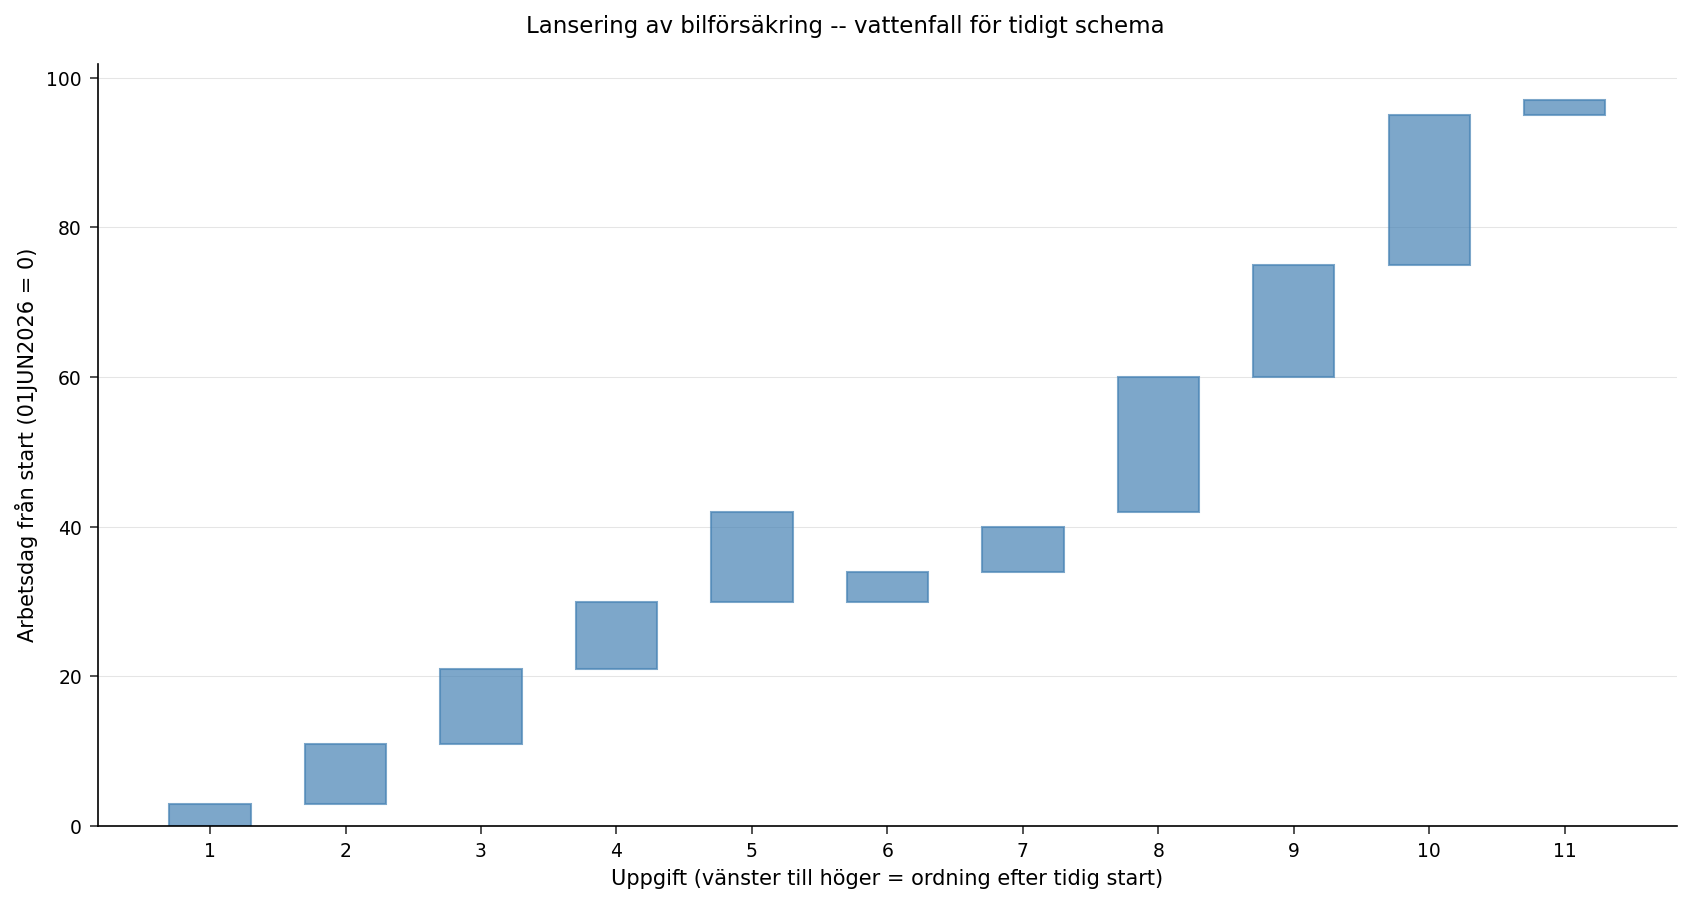

In [8]:
data gantt; STÄLL_IN sched_es;
   ord = es;          /* numeriskt x = ordning efter tidig start */
KÖR;
PROCEDUR SORTERA data=gantt; EFTER ord activity; KÖR;
data gantt; STÄLL_IN gantt; ax = _n_; KÖR;   /* kompakt x-index 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITEL 'Lansering av bilförsäkring -- vattenfall för tidigt schema';
PROCEDUR SGPLOT data=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS ETIKETT='Uppgift (vänster till höger = ordning efter tidig start)'
         integer VALUES=(1 TILL 11 EFTER 1);
   YAXIS ETIKETT='Arbetsdag från start (01JUN2026 = 0)' grid;
KÖR;
ODS GRAPHICS OFF;

Läst från vänster till höger stiger staplarna kontinuerligt uppför den kritiska kedjan. De två uppgifterna vars staplar bryter trappan -- genom att starta lägre än den föregående stapelns topp -- är tariffinlämning och godkännande, aktiviteterna som bär flyt.

## Total flyt per uppgift

Att plotta varje uppgifts totala flyt gör den kritiska vägen omisskännlig: varje kritisk uppgift ligger på noll, och endast de två regulatoriska uppgifterna reser sig över den.

                                   Total flyt per uppgift (0 = på den kritiska vägen)                                   




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Total flyt per uppgift (0 = på den kritiska vägen).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


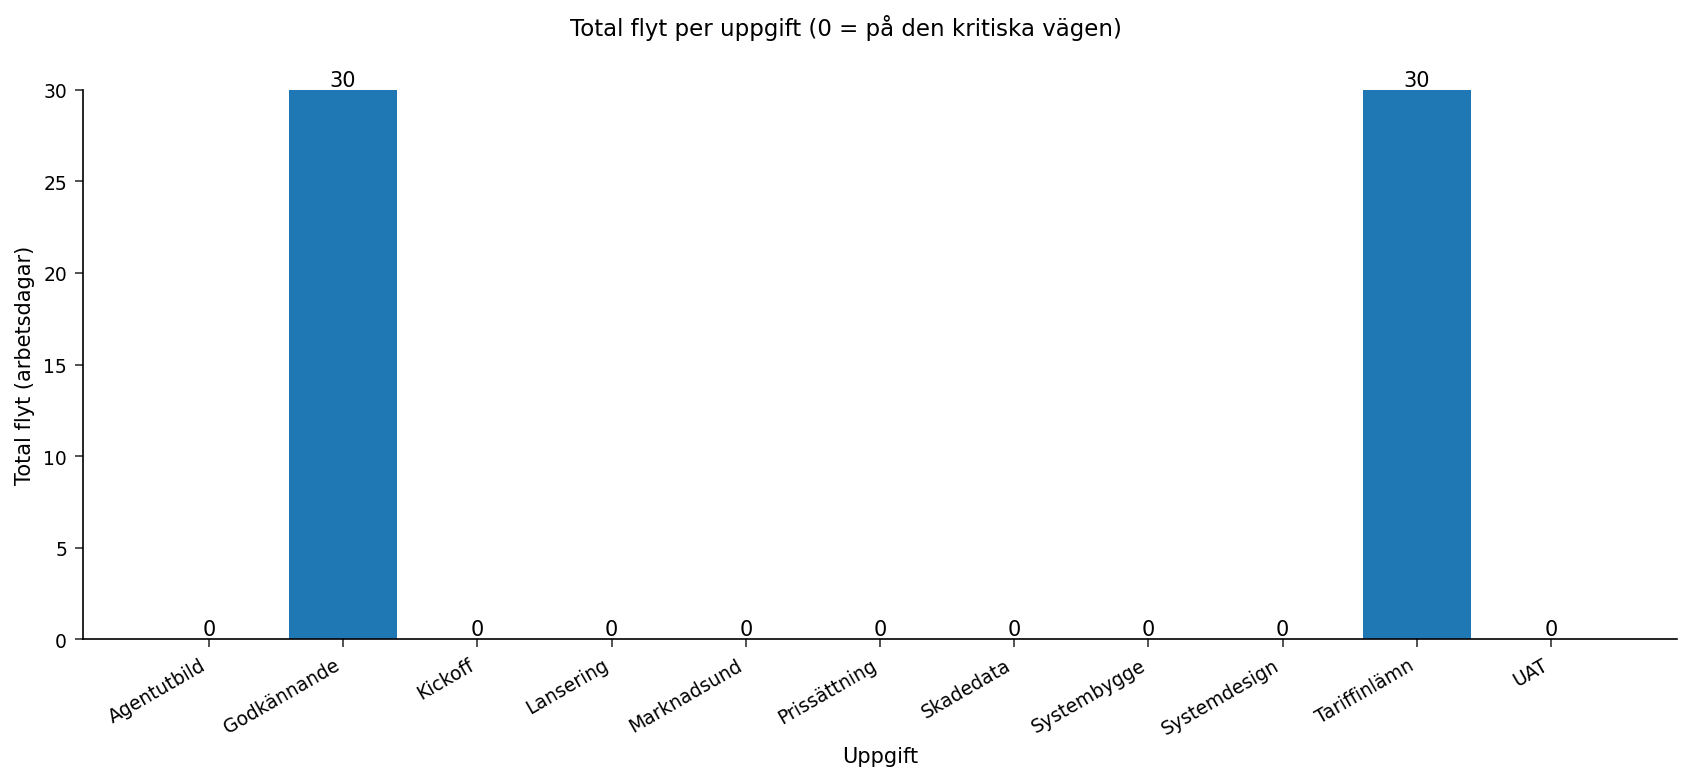

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITEL 'Total flyt per uppgift (0 = på den kritiska vägen)';
PROCEDUR SGPLOT data=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS ETIKETT='Uppgift' fitpolicy=rotatethin;
   YAXIS ETIKETT='Total flyt (arbetsdagar)';
KÖR;
ODS GRAPHICS OFF;

## Resursbelastning under det tidiga schemat

Utöver tidsplaneringen konkurrerar planen om två specialistpooler. Att expandera varje uppgift över de arbetsdagar den upptar och summera den dagliga efterfrågan ger resursbelastningsprofilen -- hur många aktuarier och utvecklare planen behöver varje dag om varje uppgift startar så tidigt som möjligt. Toppen är den mesta kapacitet programmet någonsin kräver samtidigt.

                                    Maximal daglig resursbelastning (tidigt schema)                                     

                                                  The MEANS Procedure

 Variable    Label          Maximum
 ----------------------------------
 ACTUARIES   Aktuarier            3
 DEVELOPERS  Utvecklare           3
 ----------------------------------

                          Daglig belastning av aktuarier & utvecklare under det tidiga schemat                          




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Maximal daglig resursbelastning (tidigt schema).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Daglig belastning av aktuarier & utvecklare under det tidiga schemat.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


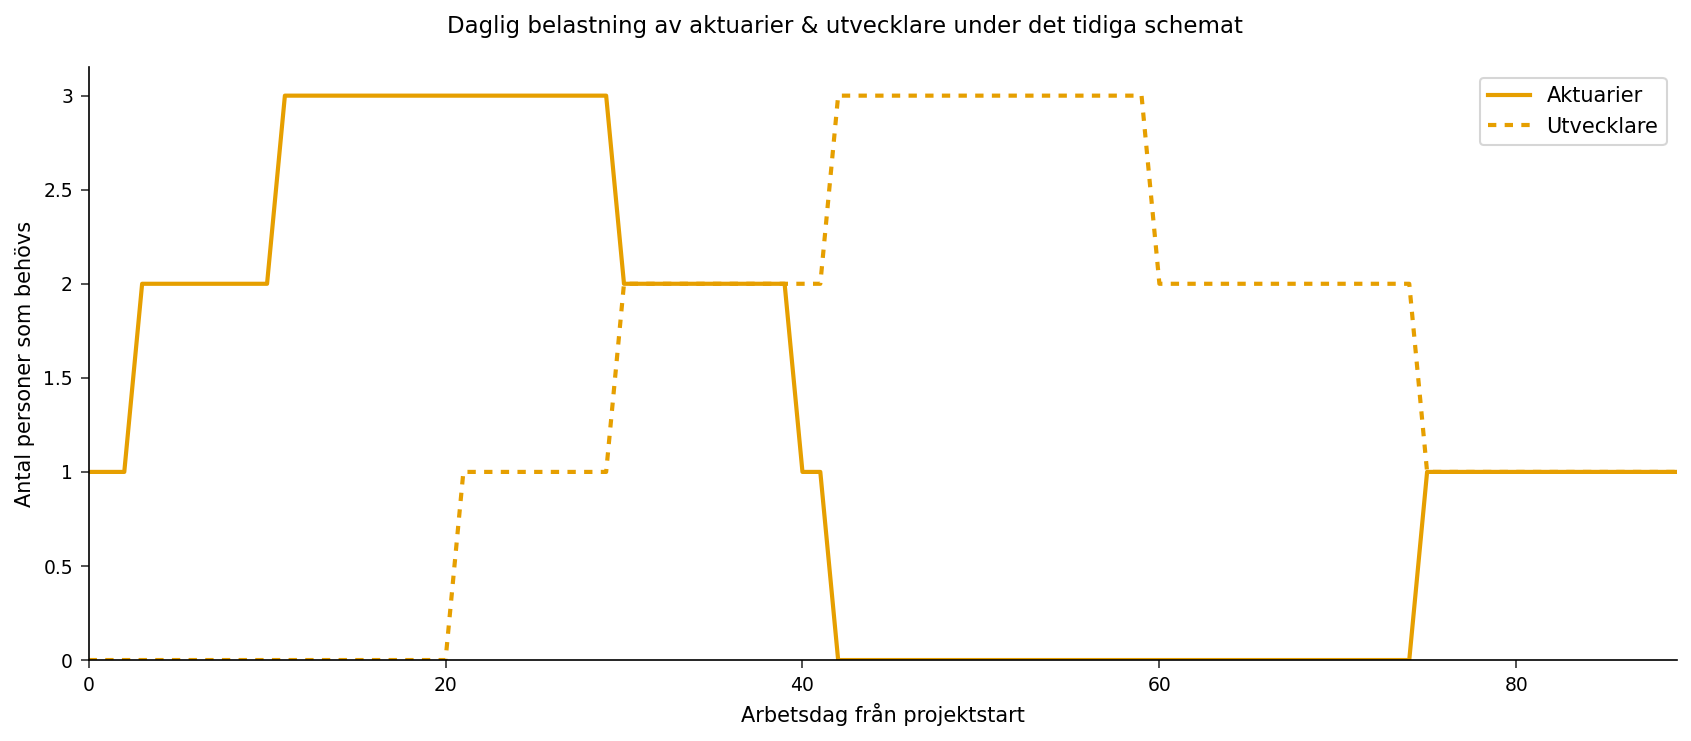

In [10]:
data LOAD;
   STÄLL_IN sched;
   GÖR d = es TILL ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      UTDATA;
   SLUT;
   BEHÅLL day a_use d_use;
KÖR;

PROCEDUR MEDELVÄRDEN data=LOAD NOPRINT NWAY;
   KLASS day;
   VARIABEL a_use d_use;
   UTDATA out=rprofile(TA_BORT=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
KÖR;
PROCEDUR SORTERA data=rprofile; EFTER day; KÖR;

TITEL 'Maximal daglig resursbelastning (tidigt schema)';
PROCEDUR MEDELVÄRDEN data=rprofile MAX maxdec=0;
   VARIABEL actuaries developers;
   ETIKETT actuaries='Aktuarier' developers='Utvecklare';
KÖR;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITEL 'Daglig belastning av aktuarier & utvecklare under det tidiga schemat';
PROCEDUR SGPLOT data=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Aktuarier';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Utvecklare';
   XAXIS ETIKETT='Arbetsdag från projektstart';
   YAXIS ETIKETT='Antal personer som behövs' MIN=0;
   keylegend / location=inside position=topright;
KÖR;
ODS GRAPHICS OFF;

## Tolkning av resultaten

- **Lanseringsdatumet bestäms av byggspåret, inte det regulatoriska spåret.** Den kritiska vägen löper Kickoff -> Marknadsundersökning -> Sammanställning av skadedata -> Prissättning -> Systemdesign -> Systembyggnad -> UAT -> Agentutbildning -> Lansering, för en makespan på 97 arbetsdagar (avslutas 13OCT2026). Var och en av dessa uppgifter har noll flyt, så varje försening på dem skjuter lanseringen dag för dag.

- **Den regulatoriska grenen har en månads slack.** Tariffinlämning och godkännande bär vardera 30 arbetsdagars total flyt. Efter att prissättningen avslutats kan de starta så sent som deras senaste startdatum och ändå återförenas med agentutbildningen i tid, eftersom den parallella systembyggnadsgrenen (systemdesign -> systembyggnad -> UAT) är den längre av de två vägarna som leder in i lanseringen. I planeringstermer är inlämningen *inte* den bindande begränsningen här -- det är byggnaden av policysystemet.

- **Specialistefterfrågan toppar i olika faser.** Belastningsprofilen visar att aktuarieefterfrågan toppar tidigt (fram till prissättning) och utvecklarefterfrågan toppar senare (fram till systembyggnaden), var och en når som mest tre personer per dag. Eftersom de två topparna infaller i olika faser kan ett litet, sekventiellt specialistteam bemanna planen -- programmet behöver inte sitt maximala antal aktuarier och utvecklare samtidigt.

**Affärsslutsats.** CPM förvandlar en lista över lanseringsuppgifter till ett handlingsbart schema: den identifierar de aktiviteter i byggspåret som försäkringsbolaget måste skydda för att nå 13OCT2026, kvantifierar den månads slack som finns tillgänglig på den regulatoriska inlämningen, och visar att förskjutna aktuarie- och utvecklartoppar låter ett smalt specialistteam leverera planen.

*Implementeringsnotering:* SAS beräknar detta med PROC CPM (SAS/OR). Jenner når samma framåt/bakåt-kritisk-väg-resultat med PROC OPTMODEL genom att lösa de två längsta-väg-linjära programmen som ligger till grund för metoden.